# test model


image 1/1 f:\projects\object-detection-for-traffic-using-yolo\test\test.jpeg: 448x640 22 vehicles, 29.7ms
Speed: 6.7ms preprocess, 29.7ms inference, 17.8ms postprocess per image at shape (1, 3, 448, 640)


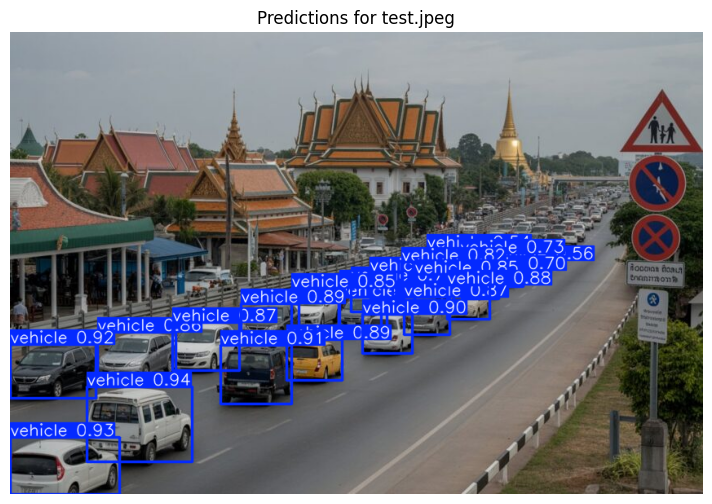

Boxes: tensor([[9.4432e+01, 4.3569e+02, 2.2328e+02, 5.2796e+02],
        [0.0000e+00, 4.9775e+02, 1.3449e+02, 5.6700e+02],
        [7.5195e-02, 3.8379e+02, 1.0595e+02, 4.4900e+02],
        [2.5812e+02, 3.8414e+02, 3.4549e+02, 4.5697e+02],
        [4.3243e+02, 3.4645e+02, 4.9355e+02, 3.9411e+02],
        [2.8337e+02, 3.3303e+02, 3.5494e+02, 3.8027e+02],
        [3.3976e+02, 3.7778e+02, 4.0794e+02, 4.2797e+02],
        [5.3677e+02, 3.1089e+02, 5.8833e+02, 3.5207e+02],
        [1.9903e+02, 3.5630e+02, 2.8165e+02, 4.1514e+02],
        [4.8336e+02, 3.2592e+02, 5.3978e+02, 3.7169e+02],
        [1.0744e+02, 3.6801e+02, 2.0320e+02, 4.2715e+02],
        [3.4550e+02, 3.1423e+02, 4.0326e+02, 3.6256e+02],
        [4.9636e+02, 2.9757e+02, 5.4449e+02, 3.3434e+02],
        [4.8081e+02, 2.8203e+02, 5.1938e+02, 3.1077e+02],
        [4.4190e+02, 2.9413e+02, 4.8173e+02, 3.2670e+02],
        [5.5225e+02, 2.7279e+02, 5.8723e+02, 3.0471e+02],
        [4.1847e+02, 3.0608e+02, 4.6945e+02, 3.4339e+02],
       

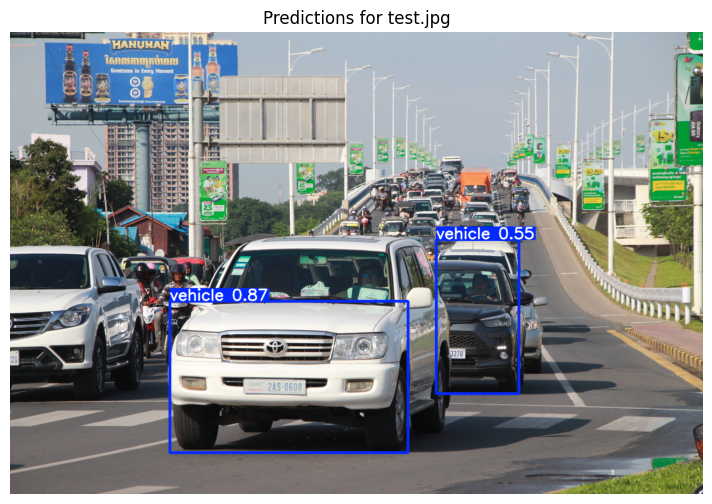

Boxes: tensor([[311.3471, 524.4462, 775.5762, 819.4507],
        [830.0516, 404.8993, 991.5882, 704.3139]], device='cuda:0')
Confidence: tensor([0.8666, 0.5495], device='cuda:0')
Class: tensor([0., 0.], device='cuda:0')

image 1/1 f:\projects\object-detection-for-traffic-using-yolo\test\test.png: 448x640 9 vehicles, 14.7ms
Speed: 2.0ms preprocess, 14.7ms inference, 1.8ms postprocess per image at shape (1, 3, 448, 640)


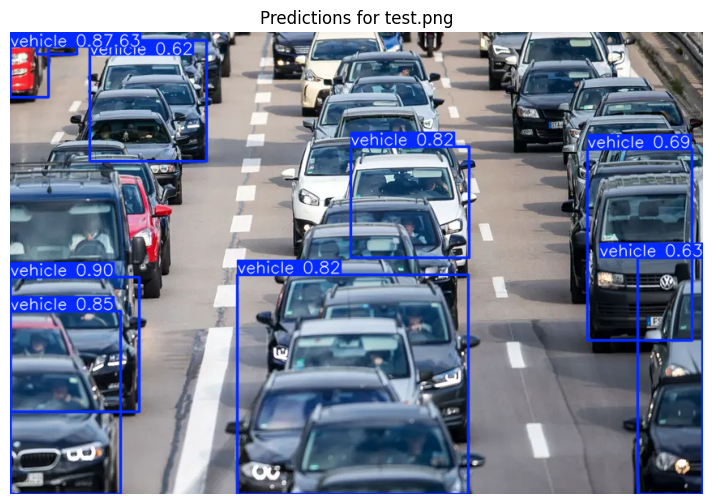

Boxes: tensor([[0.0000e+00, 3.0262e+02, 1.5958e+02, 4.6854e+02],
        [7.6331e-02, 0.0000e+00, 4.7809e+01, 8.0783e+01],
        [0.0000e+00, 3.4442e+02, 1.3679e+02, 5.7000e+02],
        [2.8045e+02, 2.9989e+02, 5.6511e+02, 5.7000e+02],
        [4.2066e+02, 1.4119e+02, 5.6675e+02, 2.7821e+02],
        [7.1238e+02, 1.4462e+02, 8.4118e+02, 3.8024e+02],
        [7.7454e+02, 2.7861e+02, 8.5480e+02, 5.7000e+02],
        [3.3147e+01, 6.4650e-01, 8.2821e+01, 2.7540e+01],
        [9.8046e+01, 1.0684e+01, 2.4260e+02, 1.5905e+02]], device='cuda:0')
Confidence: tensor([0.8952, 0.8712, 0.8543, 0.8240, 0.8196, 0.6908, 0.6333, 0.6281, 0.6197], device='cuda:0')
Class: tensor([0., 0., 0., 0., 0., 0., 0., 0., 0.], device='cuda:0')


In [1]:
from ultralytics import YOLO
import os
import random
import matplotlib.pyplot as plt
import cv2

# Load your trained model
model = YOLO("models/yolov5_1k.pt")  # adjust path

# Path to test images folder
# test_folder = "vehicle_dataset/images/test/"
test_folder = "test/"


# Get all image files in the folder
all_images = [
    os.path.join(test_folder, f)
    for f in os.listdir(test_folder)
    if f.lower().endswith((".jpg", ".jpeg", ".png"))
]

# Pick 10 random images
test_images = random.sample(all_images, min(10, len(all_images)))

# Run inference and display
for img_path in test_images:
    results = model.predict(
        source=img_path, conf=0.5, save=False
    )  # save=False, we just display
    annotated_img = results[0].plot()  # draw boxes
    annotated_img = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(10, 6))
    plt.imshow(annotated_img)
    plt.title(f"Predictions for {os.path.basename(img_path)}")
    plt.axis("off")
    plt.show()

    # Print box info
    for result in results:
        print("Boxes:", result.boxes.xyxy)
        print("Confidence:", result.boxes.conf)
        print("Class:", result.boxes.cls)